# 04 — Text Feature Diagnostics

Checks where the strong text baselines from `03_text_baselines.ipynb` come from: (1) shortcut baselines (length, language proxy) to confirm the models are not just exploiting trivial signals, and (2) TF-IDF representation variants (word vs character n-grams) to see whether a different representation helps. The conclusion is that the word-level TF-IDF baseline should remain the backbone.

> Reference numbers from `03_text_baselines.ipynb`:
>
> | task | best model | input | strat. macroF1 | grouped macroF1 |
> | --- | --- | --- | :-: | :-: |
> | topic    | TF-IDF + Linear SVM | `text_subject_body` | 0.861 | 0.804 |
> | priority | TF-IDF + Linear SVM | `text_body`         | 0.765 | 0.705 |


## 1 — Imports and configuration

Same paths, label orderings, random seed, and TF-IDF defaults as the previous notebook so this notebook is directly comparable.


In [2]:
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GroupShuffleSplit,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path("../data/processed/frozen_dataset.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.2

TOPIC_ORDER = ["administrative", "course-exam", "event", "deadline-action", "advertisement"]
PRIORITY_ORDER = ["High", "Medium", "Low"]
TEXT_FIELDS = ["text_subject", "text_body", "text_subject_body"]
TASK_LABELS = {"topic": TOPIC_ORDER, "priority": PRIORITY_ORDER}

# Same TF-IDF defaults as 03_text_baselines.ipynb (the reference baseline).
BASE_TFIDF = dict(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=False,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 80)

print("Data:", DATA_PATH.resolve())


Data: D:\UniGe\3\NLP\NLP-project\data\processed\frozen_dataset.csv


## 2 — Load the frozen dataset

Same artifact as the previous notebook. Empty text cells are filled with `""` for vectorizer compatibility.


In [3]:
df = pd.read_csv(DATA_PATH)
for col in TEXT_FIELDS:
    df[col] = df[col].fillna("").astype(str)

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print()
print("Topic counts:")
print(df["topic"].value_counts().reindex(TOPIC_ORDER).to_string())
print()
print("Priority counts:")
print(df["priority"].value_counts().reindex(PRIORITY_ORDER).to_string())


Shape   : (919, 8)
Columns : ['id', 'subject', 'body_plain', 'topic', 'priority', 'text_subject', 'text_body', 'text_subject_body']

Topic counts:
topic
administrative     159
course-exam        267
event              189
deadline-action    197
advertisement      107

Priority counts:
priority
High      272
Medium    309
Low       338


## 3 — Splits: stratified and grouped-by-subject

We pre-compute **two** index splits per task — exactly the same logic as `03_text_baselines.ipynb` so results are directly comparable:

- **Stratified** (`train_test_split` + `stratify=y`): the optimistic, row-level split.
- **Grouped-by-subject** (`GroupShuffleSplit` with `groups=df["text_subject"]`): the honest split that prevents identical cleaned subjects from leaking between train and test.

The same grouped split is shared across topic and priority so the "drop" is comparable.


In [4]:
indices = np.arange(len(df))

# Stratified splits (per task).
idx_train_topic, idx_test_topic = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE,
    stratify=df["topic"].values,
)
idx_train_priority, idx_test_priority = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE,
    stratify=df["priority"].values,
)

SPLITS_STRAT = {
    "topic": (idx_train_topic, idx_test_topic),
    "priority": (idx_train_priority, idx_test_priority),
}

# Subject-grouped split (single split, shared across both tasks).
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
idx_train_g, idx_test_g = next(gss.split(indices, groups=df["text_subject"].values))
SPLITS_GROUPED = (idx_train_g, idx_test_g)

print("Stratified:")
for task, (tr, te) in SPLITS_STRAT.items():
    print(f"  {task:<8} -> train={len(tr):>4}  test={len(te):>4}")

overlap = len(set(df.loc[idx_train_g, "text_subject"]) & set(df.loc[idx_test_g, "text_subject"]))
print(f"\nGrouped-by-subject:")
print(f"  shared    -> train={len(idx_train_g):>4}  test={len(idx_test_g):>4}")
print(f"  subject overlap (must be 0): {overlap}")


Stratified:
  topic    -> train= 735  test= 184
  priority -> train= 735  test= 184

Grouped-by-subject:
  shared    -> train= 727  test= 192
  subject overlap (must be 0): 0


## 4 — Helpers: classifiers, metrics, results recorder

Three small utilities reused across every experiment in this notebook.

- `build_classifier(name)` — returns either a `LogisticRegression` or a `LinearSVC`, both with `class_weight="balanced"` (consistent with `03_text_baselines.ipynb`).
- `cv_macro_f1(estimator, X, y)` — 5-fold stratified CV macro-F1.
- `evaluate(estimator, Xtr, ytr, Xte, yte)` — fits on train, scores on test, returns metrics + predictions.
- `record(...)` — appends one row to the master `RESULTS` list, with a uniform schema for the spec's required tables.


In [5]:
MODEL_NAMES = {
    "logreg": "Logistic Regression",
    "linsvc": "Linear SVM",
}


def build_classifier(name: str):
    if name == "logreg":
        return LogisticRegression(
            max_iter=3000, class_weight="balanced", solver="lbfgs",
        )
    if name == "linsvc":
        return LinearSVC(class_weight="balanced", max_iter=5000)
    raise ValueError(f"Unknown classifier: {name}")


def cv_macro_f1(estimator, X, y, n_splits: int = 5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(estimator, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    return float(scores.mean()), float(scores.std())


def evaluate(estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f,
        "weighted_f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }
    return estimator, y_pred, metrics


RESULTS: list[dict] = []
PREDS: dict = {}        # (task, feature_set, input_field, model, split_type) -> (y_test, y_pred)
FITTED: dict = {}        # same keys -> fitted estimator
NUM_FEATURES: dict = {}  # same keys -> int


def record(task, split_type, feature_set, input_field, model, metrics,
           cv_mean=None, cv_std=None, num_features=None):
    row = {
        "task": task,
        "split_type": split_type,
        "feature_set": feature_set,
        "input_field": input_field,
        "model": model,
        "cv_macro_f1_mean": None if cv_mean is None else round(cv_mean, 4),
        "cv_macro_f1_std":  None if cv_std  is None else round(cv_std,  4),
        "num_features": num_features,
        **{k: round(v, 4) for k, v in metrics.items()},
    }
    RESULTS.append(row)
    return row


print("Helpers ready.")


Helpers ready.


## 5 — Shortcut baselines

Measures how far a non-semantic model can get using only length and a language proxy. If shortcuts stay well below the TF-IDF baseline, the baseline is driven by content rather than trivial signals. We test length-only, language-only, and length+language.


### 5.1 — Build length and language-proxy features

Length features are simple character / word counts. Language-proxy features are computed from two **small, hand-curated function-word lists** (the EDA already showed Italian and English carry the dataset). The `lang_proxy` rule is intentionally crude — that's the point: we want to see how much classification can be done from such a coarse signal alone.


In [6]:
ITALIAN_FUNCTION_WORDS = {
    "il", "lo", "la", "i", "gli", "le",
    "di", "a", "da", "in", "con", "su", "per", "tra", "fra",
    "che", "non", "una", "un", "uno",
    "sono", "del", "della", "delle", "degli", "dello", "dei",
    "alle", "agli", "alla", "alle",
    "entro", "iscrizione",
    "mercoledi", "giovedi", "martedi", "lunedi", "venerdi", "sabato", "domenica",
    "corso", "esame", "studenti", "scadenza",
}
ENGLISH_FUNCTION_WORDS = {
    "the", "and", "of", "to", "in", "for", "with", "is", "are", "was",
    "you", "your", "this", "that", "by", "from", "on", "at",
    "deadline", "submit", "registration", "please",
    "we", "our", "as", "be", "an", "or", "if",
}

# Allow alphanumerics, accented Italian letters, hyphens and underscores
WORD_RE = re.compile(r"[A-Za-z\u00C0-\u017F][A-Za-z\u00C0-\u017F\-_]*")


def tokenize_simple(text: str) -> list[str]:
    return WORD_RE.findall(text.lower())


def lang_proxy_for(text: str):
    toks = tokenize_simple(text)
    n = len(toks)
    if n == 0:
        return {
            "italian_function_word_count": 0,
            "english_function_word_count": 0,
            "italian_ratio": 0.0,
            "english_ratio": 0.0,
            "lang_proxy": "unknown",
        }
    it = sum(1 for t in toks if t in ITALIAN_FUNCTION_WORDS)
    en = sum(1 for t in toks if t in ENGLISH_FUNCTION_WORDS)
    it_ratio = it / n
    en_ratio = en / n

    # crude classifier: dominant language wins; both / neither -> mixed / unknown
    if it_ratio == 0 and en_ratio == 0:
        proxy = "unknown"
    elif it_ratio >= 1.5 * en_ratio and it_ratio > 0.01:
        proxy = "it"
    elif en_ratio >= 1.5 * it_ratio and en_ratio > 0.01:
        proxy = "en"
    else:
        proxy = "mixed"

    return {
        "italian_function_word_count": it,
        "english_function_word_count": en,
        "italian_ratio": it_ratio,
        "english_ratio": en_ratio,
        "lang_proxy": proxy,
    }


# Length features (numeric).
df["subject_char_len"]      = df["text_subject"].str.len()
df["subject_word_len"]      = df["text_subject"].str.split().str.len().fillna(0).astype(int)
df["body_char_len"]         = df["text_body"].str.len()
df["body_word_len"]         = df["text_body"].str.split().str.len().fillna(0).astype(int)
df["subject_body_char_len"] = df["text_subject_body"].str.len()
df["subject_body_word_len"] = df["text_subject_body"].str.split().str.len().fillna(0).astype(int)

LENGTH_FEATURES = [
    "subject_char_len", "subject_word_len",
    "body_char_len", "body_word_len",
    "subject_body_char_len", "subject_body_word_len",
]

# Language-proxy features computed from text_subject_body (the richest source).
lang_rows = df["text_subject_body"].apply(lang_proxy_for).tolist()
lang_df = pd.DataFrame(lang_rows, index=df.index)
df["italian_function_word_count"] = lang_df["italian_function_word_count"]
df["english_function_word_count"] = lang_df["english_function_word_count"]
df["italian_ratio"]               = lang_df["italian_ratio"]
df["english_ratio"]               = lang_df["english_ratio"]
df["lang_proxy"]                  = lang_df["lang_proxy"]
df["is_italian"] = (df["lang_proxy"] == "it").astype(int)
df["is_english"] = (df["lang_proxy"] == "en").astype(int)
df["is_mixed"]   = (df["lang_proxy"] == "mixed").astype(int)
df["is_unknown"] = (df["lang_proxy"] == "unknown").astype(int)

LANG_NUMERIC = [
    "italian_function_word_count", "english_function_word_count",
    "italian_ratio", "english_ratio",
    "is_italian", "is_english", "is_mixed", "is_unknown",
]
LANG_CATEGORICAL = ["lang_proxy"]

print("Length feature stats:")
print(df[LENGTH_FEATURES].describe().round(1).T[["mean", "std", "min", "50%", "max"]])
print()
print("Language proxy distribution:")
print(df["lang_proxy"].value_counts().to_string())


Length feature stats:
                         mean     std   min     50%      max
subject_char_len         62.1    28.1   6.0    59.0    171.0
subject_word_len          8.7     4.1   2.0     8.0     27.0
body_char_len          1254.0  1148.8   0.0   916.0  13789.0
body_word_len           189.1   184.7   0.0   137.0   2382.0
subject_body_char_len  1333.8  1154.3  40.0  1000.0  13878.0
subject_body_word_len   199.7   185.4   6.0   148.0   2395.0

Language proxy distribution:
lang_proxy
it       561
en       243
mixed    115


### 5.2 — Run the three shortcut baselines

Pipelines:

- **length only**:        `StandardScaler → classifier`
- **language only**:      `ColumnTransformer(StandardScaler on numeric, OneHotEncoder on lang_proxy) → classifier`
- **length + language**:  same as language only, plus the length numerics.

Each combination is evaluated on **both** the stratified split and the grouped-by-subject split.


In [7]:
def build_shortcut_pipeline(feature_set: str, model_name: str):
    # feature_set in {'length', 'language', 'length_language'}
    if feature_set == "length":
        # All numeric; StandardScaler is enough.
        pre = ColumnTransformer(
            transformers=[("num", StandardScaler(), LENGTH_FEATURES)],
            remainder="drop",
        )
    elif feature_set == "language":
        pre = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), LANG_NUMERIC),
                ("cat", OneHotEncoder(handle_unknown="ignore"), LANG_CATEGORICAL),
            ],
            remainder="drop",
        )
    elif feature_set == "length_language":
        pre = ColumnTransformer(
            transformers=[
                ("num_len", StandardScaler(), LENGTH_FEATURES),
                ("num_lang", StandardScaler(), LANG_NUMERIC),
                ("cat_lang", OneHotEncoder(handle_unknown="ignore"), LANG_CATEGORICAL),
            ],
            remainder="drop",
        )
    else:
        raise ValueError(feature_set)
    return Pipeline([("pre", pre), ("clf", build_classifier(model_name))])


def run_shortcut(task: str, feature_set: str, model_name: str):
    feature_cols_all = list(LENGTH_FEATURES) + list(LANG_NUMERIC) + list(LANG_CATEGORICAL)
    X_full = df[feature_cols_all]

    # Stratified
    idx_tr, idx_te = SPLITS_STRAT[task]
    X_tr, X_te = X_full.loc[idx_tr], X_full.loc[idx_te]
    y_tr = df.loc[idx_tr, task].values
    y_te = df.loc[idx_te, task].values

    pipe = build_shortcut_pipeline(feature_set, model_name)
    cv_mean, cv_std = cv_macro_f1(pipe, X_tr, y_tr)
    pipe = build_shortcut_pipeline(feature_set, model_name)
    pipe, y_pred, metrics = evaluate(pipe, X_tr, y_tr, X_te, y_te)
    n_feat = pipe.named_steps["pre"].transform(X_tr.iloc[:1]).shape[1]
    record(task, "stratified", feature_set, "—", MODEL_NAMES[model_name],
           metrics, cv_mean, cv_std, n_feat)
    PREDS[(task, feature_set, "—", model_name, "stratified")] = (y_te, y_pred)
    print(f"[strat]   {task:<8} | {feature_set:<16} | {model_name:<6} | "
          f"CV={cv_mean:.3f}±{cv_std:.3f} | acc={metrics['accuracy']:.3f} "
          f"macroF1={metrics['macro_f1']:.3f} | n_feat={n_feat}")

    # Grouped-by-subject
    idx_tr_g, idx_te_g = SPLITS_GROUPED
    X_tr_g, X_te_g = X_full.loc[idx_tr_g], X_full.loc[idx_te_g]
    y_tr_g = df.loc[idx_tr_g, task].values
    y_te_g = df.loc[idx_te_g, task].values
    pipe_g = build_shortcut_pipeline(feature_set, model_name)
    pipe_g, y_pred_g, metrics_g = evaluate(pipe_g, X_tr_g, y_tr_g, X_te_g, y_te_g)
    n_feat_g = pipe_g.named_steps["pre"].transform(X_tr_g.iloc[:1]).shape[1]
    record(task, "grouped_subject", feature_set, "—", MODEL_NAMES[model_name],
           metrics_g, num_features=n_feat_g)
    PREDS[(task, feature_set, "—", model_name, "grouped_subject")] = (y_te_g, y_pred_g)
    print(f"[grouped] {task:<8} | {feature_set:<16} | {model_name:<6} | "
          f"acc={metrics_g['accuracy']:.3f} macroF1={metrics_g['macro_f1']:.3f}")


for task in ("topic", "priority"):
    print(f"\n=== Task: {task} ===")
    for feature_set in ("length", "language", "length_language"):
        for model_name in ("logreg", "linsvc"):
            run_shortcut(task, feature_set, model_name)



=== Task: topic ===
[strat]   topic    | length           | logreg | CV=0.303±0.014 | acc=0.391 macroF1=0.341 | n_feat=6
[grouped] topic    | length           | logreg | acc=0.448 macroF1=0.382
[strat]   topic    | length           | linsvc | CV=0.301±0.042 | acc=0.418 macroF1=0.327 | n_feat=6
[grouped] topic    | length           | linsvc | acc=0.510 macroF1=0.423
[strat]   topic    | language         | logreg | CV=0.346±0.012 | acc=0.397 macroF1=0.330 | n_feat=11
[grouped] topic    | language         | logreg | acc=0.380 macroF1=0.316
[strat]   topic    | language         | linsvc | CV=0.326±0.020 | acc=0.402 macroF1=0.325 | n_feat=11
[grouped] topic    | language         | linsvc | acc=0.396 macroF1=0.316
[strat]   topic    | length_language  | logreg | CV=0.417±0.029 | acc=0.413 macroF1=0.379 | n_feat=17
[grouped] topic    | length_language  | logreg | acc=0.396 macroF1=0.368
[strat]   topic    | length_language  | linsvc | CV=0.397±0.041 | acc=0.440 macroF1=0.369 | n_feat=17
[gro

## 6 — TF-IDF representation variants

We compare word and character TF-IDF variants against the previous `word_1_2gram` baseline (all share `min_df=2, max_df=0.95, sublinear_tf=True, lowercase=False`): `word_1gram`, `word_1_2gram`, `char_3_5gram`, `char_3_6gram`, and the `word_1_2 + char_3_5` union. (`word_1_3gram` is included as an extra variant beyond the report's tables.) Linear SVM is the main model.


### 6.1 — TF-IDF variant factories


In [8]:
def build_word_tfidf(ngram_range):
    return TfidfVectorizer(
        analyzer="word", ngram_range=ngram_range,
        min_df=2, max_df=0.95, sublinear_tf=True, lowercase=False,
    )


def build_char_tfidf(ngram_range):
    return TfidfVectorizer(
        analyzer="char_wb", ngram_range=ngram_range,
        min_df=2, max_df=0.95, sublinear_tf=True, lowercase=False,
    )


def build_union_tfidf(word_ngram=(1, 2), char_ngram=(3, 5)):
    return FeatureUnion([
        ("word_tfidf", build_word_tfidf(word_ngram)),
        ("char_tfidf", build_char_tfidf(char_ngram)),
    ])


def build_tfidf_variant(name: str):
    if name == "word_1gram":
        return build_word_tfidf((1, 1))
    if name == "word_1_2gram":
        return build_word_tfidf((1, 2))
    if name == "word_1_3gram":
        return build_word_tfidf((1, 3))
    if name == "char_3_5gram":
        return build_char_tfidf((3, 5))
    if name == "char_3_6gram":
        return build_char_tfidf((3, 6))
    if name == "word_1_2_plus_char_3_5":
        return build_union_tfidf(word_ngram=(1, 2), char_ngram=(3, 5))
    raise ValueError(name)


TFIDF_VARIANTS = [
    "word_1gram",
    "word_1_2gram",
    "word_1_3gram",
    "char_3_5gram",
    "char_3_6gram",
    "word_1_2_plus_char_3_5",
]
print("Variants:", TFIDF_VARIANTS)


Variants: ['word_1gram', 'word_1_2gram', 'word_1_3gram', 'char_3_5gram', 'char_3_6gram', 'word_1_2_plus_char_3_5']


### 6.2 — Run all TF-IDF variants

Loop over `(task, variant, input_field, model)` on the **stratified** split. We run every variant with **Linear SVM** (the strong default). Logistic Regression is run only on the previous-baseline variant (`word_1_2gram`) and the strongest combined variant (`word_1_2 + char_3_5`) on the winning input field for each task — enough to confirm the LinSVC vs LogReg gap from `03_text_baselines.ipynb` still holds with the improved representation.


In [9]:
TOPIC_FIELDS_TO_TEST = ["text_subject_body", "text_body"]
PRIORITY_FIELDS_TO_TEST = ["text_body", "text_subject_body"]
TASK_FIELDS = {"topic": TOPIC_FIELDS_TO_TEST, "priority": PRIORITY_FIELDS_TO_TEST}


def run_tfidf_variant(task: str, variant: str, field: str, model_name: str,
                      do_grouped: bool = False):
    # Stratified evaluation
    idx_tr, idx_te = SPLITS_STRAT[task]
    X_tr = df.loc[idx_tr, field].values
    X_te = df.loc[idx_te, field].values
    y_tr = df.loc[idx_tr, task].values
    y_te = df.loc[idx_te, task].values

    pipe = Pipeline([("vec", build_tfidf_variant(variant)),
                     ("clf", build_classifier(model_name))])
    cv_mean, cv_std = cv_macro_f1(pipe, X_tr, y_tr)

    pipe = Pipeline([("vec", build_tfidf_variant(variant)),
                     ("clf", build_classifier(model_name))])
    pipe, y_pred, metrics = evaluate(pipe, X_tr, y_tr, X_te, y_te)
    n_feat = pipe.named_steps["vec"].transform(X_tr[:1]).shape[1]

    key = (task, variant, field, model_name, "stratified")
    PREDS[key] = (y_te, y_pred)
    FITTED[key] = pipe
    NUM_FEATURES[key] = n_feat
    record(task, "stratified", variant, field, MODEL_NAMES[model_name],
           metrics, cv_mean, cv_std, n_feat)
    print(f"[strat]   {task:<8} | {variant:<22} | {field:<18} | {model_name:<6} | "
          f"CV={cv_mean:.3f}±{cv_std:.3f} | acc={metrics['accuracy']:.3f} "
          f"macroF1={metrics['macro_f1']:.3f} | n_feat={n_feat}")

    if do_grouped:
        idx_tr_g, idx_te_g = SPLITS_GROUPED
        X_tr_g = df.loc[idx_tr_g, field].values
        X_te_g = df.loc[idx_te_g, field].values
        y_tr_g = df.loc[idx_tr_g, task].values
        y_te_g = df.loc[idx_te_g, task].values
        pipe_g = Pipeline([("vec", build_tfidf_variant(variant)),
                           ("clf", build_classifier(model_name))])
        pipe_g, y_pred_g, metrics_g = evaluate(pipe_g, X_tr_g, y_tr_g, X_te_g, y_te_g)
        n_feat_g = pipe_g.named_steps["vec"].transform(X_tr_g[:1]).shape[1]
        key_g = (task, variant, field, model_name, "grouped_subject")
        PREDS[key_g] = (y_te_g, y_pred_g)
        FITTED[key_g] = pipe_g
        NUM_FEATURES[key_g] = n_feat_g
        record(task, "grouped_subject", variant, field, MODEL_NAMES[model_name],
               metrics_g, num_features=n_feat_g)
        print(f"[grouped] {task:<8} | {variant:<22} | {field:<18} | {model_name:<6} | "
              f"acc={metrics_g['accuracy']:.3f} macroF1={metrics_g['macro_f1']:.3f}")


for task in ("topic", "priority"):
    print(f"\n=== Task: {task} ===")
    for field in TASK_FIELDS[task]:
        for variant in TFIDF_VARIANTS:
            run_tfidf_variant(task, variant, field, "linsvc", do_grouped=False)



=== Task: topic ===
[strat]   topic    | word_1gram             | text_subject_body  | linsvc | CV=0.842±0.039 | acc=0.864 macroF1=0.853 | n_feat=6336
[strat]   topic    | word_1_2gram           | text_subject_body  | linsvc | CV=0.844±0.035 | acc=0.870 macroF1=0.861 | n_feat=23341
[strat]   topic    | word_1_3gram           | text_subject_body  | linsvc | CV=0.833±0.034 | acc=0.853 macroF1=0.841 | n_feat=41365
[strat]   topic    | char_3_5gram           | text_subject_body  | linsvc | CV=0.841±0.026 | acc=0.875 macroF1=0.863 | n_feat=47439
[strat]   topic    | char_3_6gram           | text_subject_body  | linsvc | CV=0.840±0.027 | acc=0.875 macroF1=0.863 | n_feat=71206
[strat]   topic    | word_1_2_plus_char_3_5 | text_subject_body  | linsvc | CV=0.845±0.034 | acc=0.875 macroF1=0.866 | n_feat=70780
[strat]   topic    | word_1gram             | text_body          | linsvc | CV=0.823±0.038 | acc=0.853 macroF1=0.838 | n_feat=6267
[strat]   topic    | word_1_2gram           | text_body  

### 6.3 — Logistic Regression sanity check

We confirm the LinSVC > LogReg pattern from `03_text_baselines.ipynb` still holds for the two strongest text representations.


In [10]:
SANITY = [
    ("topic",    "word_1_2gram",            "text_subject_body"),
    ("topic",    "word_1_2_plus_char_3_5",  "text_subject_body"),
    ("priority", "word_1_2gram",            "text_body"),
    ("priority", "word_1_2_plus_char_3_5",  "text_body"),
]
for task, variant, field in SANITY:
    run_tfidf_variant(task, variant, field, "logreg", do_grouped=False)


[strat]   topic    | word_1_2gram           | text_subject_body  | logreg | CV=0.820±0.022 | acc=0.832 macroF1=0.824 | n_feat=23341
[strat]   topic    | word_1_2_plus_char_3_5 | text_subject_body  | logreg | CV=0.836±0.025 | acc=0.864 macroF1=0.857 | n_feat=70780
[strat]   priority | word_1_2gram           | text_body          | logreg | CV=0.722±0.022 | acc=0.734 macroF1=0.729 | n_feat=22603
[strat]   priority | word_1_2_plus_char_3_5 | text_body          | logreg | CV=0.733±0.037 | acc=0.739 macroF1=0.738 | n_feat=69344


## 7 — Stratified results tables

Three tables that the spec requires:

- **Table 1**: shortcut baselines (length / language / length+language).
- **Table 2**: TF-IDF representation comparison.
- **Table 3**: stratified vs grouped for the best representation per task (built later, after we run the grouped re-evaluation in §8).


In [11]:
results_df = pd.DataFrame(RESULTS)
results_df.head()


,task,split_type,feature_set,input_field,model,cv_macro_f1_mean,cv_macro_f1_std,num_features,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,topic,stratified,length,—,Logistic Regression,0.3027,0.0143,6,0.3913,0.3597,0.3541,0.3408,0.3705
1,topic,grouped_subject,length,—,Logistic Regression,NaN,NaN,6,0.4479,0.3954,0.4008,0.3820,0.4286
2,topic,stratified,length,—,Linear SVM,0.3013,0.0418,6,0.4185,0.4102,0.3544,0.3271,0.3635
3,topic,grouped_subject,length,—,Linear SVM,NaN,NaN,6,0.5104,0.5091,0.4383,0.4230,0.4652
4,topic,stratified,language,—,Logistic Regression,0.3465,0.0116,11,0.3967,0.3047,0.3896,0.3304,0.3542


### Table 1 — Shortcut baselines (stratified)


In [12]:
SHORTCUT_SETS = ["length", "language", "length_language"]

table1 = (results_df[(results_df["split_type"] == "stratified")
                     & (results_df["feature_set"].isin(SHORTCUT_SETS))]
          .copy()
          .sort_values(["task", "feature_set", "model"]))
table1[["task", "feature_set", "model",
        "cv_macro_f1_mean", "cv_macro_f1_std",
        "accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1",
        "num_features"]]


,task,feature_set,model,cv_macro_f1_mean,cv_macro_f1_std,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,num_features
18,priority,language,Linear SVM,0.4672,0.0477,0.4837,0.4567,0.4680,0.4216,0.4291,11
16,priority,language,Logistic Regression,0.4669,0.0517,0.5054,0.5000,0.4908,0.4574,0.4646,11
14,priority,length,Linear SVM,0.4136,0.0548,0.4076,0.4065,0.4178,0.4059,0.4010,6
12,priority,length,Logistic Regression,0.4160,0.0485,0.3696,0.3669,0.3856,0.3596,0.3517,6
22,priority,length_language,Linear SVM,0.5217,0.0482,0.4837,0.4602,0.4701,0.4495,0.4574,17
20,priority,length_language,Logistic Regression,0.5251,0.0476,0.4946,0.4771,0.4824,0.4619,0.4683,17
6,topic,language,Linear SVM,0.3264,0.0198,0.4022,0.2952,0.3672,0.3247,0.3570,11
4,topic,language,Logistic Regression,0.3465,0.0116,0.3967,0.3047,0.3896,0.3304,0.3542,11
2,topic,length,Linear SVM,0.3013,0.0418,0.4185,0.4102,0.3544,0.3271,0.3635,6
0,topic,length,Logistic Regression,0.3027,0.0143,0.3913,0.3597,0.3541,0.3408,0.3705,6


### Table 2 — TF-IDF representation comparison (stratified, Linear SVM)


In [13]:
table2 = (results_df[(results_df["split_type"] == "stratified")
                     & (results_df["feature_set"].isin(TFIDF_VARIANTS))
                     & (results_df["model"] == "Linear SVM")]
          .copy()
          .sort_values(["task", "input_field", "macro_f1"], ascending=[True, True, False]))
table2[["task", "feature_set", "input_field", "model",
        "cv_macro_f1_mean", "cv_macro_f1_std",
        "accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1",
        "num_features"]]


,task,feature_set,input_field,model,cv_macro_f1_mean,cv_macro_f1_std,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,num_features
37,priority,word_1_2gram,text_body,Linear SVM,0.7371,0.0333,0.7663,0.7650,0.7665,0.7652,0.7670,22603
36,priority,word_1gram,text_body,Linear SVM,0.7479,0.0348,0.7500,0.7474,0.7496,0.7482,0.7499,6224
38,priority,word_1_3gram,text_body,Linear SVM,0.7329,0.0384,0.7391,0.7376,0.7373,0.7372,0.7402,39875
41,priority,word_1_2_plus_char_3_5,text_body,Linear SVM,0.7512,0.0333,0.7391,0.7362,0.7381,0.7367,0.7395,69344
40,priority,char_3_6gram,text_body,Linear SVM,0.7513,0.0348,0.7337,0.7303,0.7306,0.7303,0.7344,70043
39,priority,char_3_5gram,text_body,Linear SVM,0.7451,0.0336,0.7283,0.7263,0.7257,0.7258,0.7295,46741
43,priority,word_1_2gram,text_subject_body,Linear SVM,0.7386,0.0357,0.7609,0.7579,0.7599,0.7586,0.7609,23326
42,priority,word_1gram,text_subject_body,Linear SVM,0.7471,0.0302,0.7554,0.7553,0.7542,0.7545,0.7567,6302
44,priority,word_1_3gram,text_subject_body,Linear SVM,0.7364,0.0383,0.7446,0.7440,0.7426,0.7431,0.7459,41398
47,priority,word_1_2_plus_char_3_5,text_subject_body,Linear SVM,0.7525,0.0348,0.7337,0.7321,0.7332,0.7321,0.7346,70858


### Best stratified text representation per task

We pick the (variant, input_field) with the highest stratified test macro-F1 — this is what we will re-evaluate under the grouped-by-subject split next.


In [14]:
def best_tfidf_row(task: str):
    sub = (results_df[(results_df["task"] == task)
                      & (results_df["split_type"] == "stratified")
                      & (results_df["feature_set"].isin(TFIDF_VARIANTS))
                      & (results_df["model"] == "Linear SVM")]
           .sort_values("macro_f1", ascending=False))
    return sub.iloc[0]


BEST_TFIDF = {task: best_tfidf_row(task) for task in ("topic", "priority")}
for task, row in BEST_TFIDF.items():
    print(f"[best stratified] {task:<8}: feature_set={row['feature_set']:<22} "
          f"field={row['input_field']:<18} | macroF1={row['macro_f1']:.3f} "
          f"acc={row['accuracy']:.3f} (n_feat={row['num_features']})")


[best stratified] topic   : feature_set=char_3_5gram           field=text_body          | macroF1=0.866 acc=0.875 (n_feat=46769)
[best stratified] priority: feature_set=word_1_2gram           field=text_body          | macroF1=0.765 acc=0.766 (n_feat=22603)


## 8 — Grouped-by-subject re-evaluation of the best representations

We now run the **best stratified text representation** for each task under the grouped-by-subject split — same protocol as §8 of `03_text_baselines.ipynb`. The drop tells us whether the improvement is robust to template leakage or whether it was inflated by repeated subjects on both sides of the row-level split.


In [15]:
def evaluate_best_grouped(task: str):
    row = BEST_TFIDF[task]
    variant = row["feature_set"]
    field = row["input_field"]
    run_tfidf_variant(task, variant, field, "linsvc", do_grouped=True)


for task in ("topic", "priority"):
    evaluate_best_grouped(task)

# Also re-run the previous baseline (word_1_2gram on the same field) under the
# grouped split, so we can compare "improved vs old" under the honest split.
for task in ("topic", "priority"):
    field = BEST_TFIDF[task]["input_field"]
    run_tfidf_variant(task, "word_1_2gram", field, "linsvc", do_grouped=True)

# Refresh the global DataFrame after adding new rows.
results_df = pd.DataFrame(RESULTS)


[strat]   topic    | char_3_5gram           | text_body          | linsvc | CV=0.829±0.038 | acc=0.875 macroF1=0.866 | n_feat=46769
[grouped] topic    | char_3_5gram           | text_body          | linsvc | acc=0.802 macroF1=0.783
[strat]   priority | word_1_2gram           | text_body          | linsvc | CV=0.737±0.033 | acc=0.766 macroF1=0.765 | n_feat=22603
[grouped] priority | word_1_2gram           | text_body          | linsvc | acc=0.682 macroF1=0.684
[strat]   topic    | word_1_2gram           | text_body          | linsvc | CV=0.824±0.039 | acc=0.859 macroF1=0.846 | n_feat=22648
[grouped] topic    | word_1_2gram           | text_body          | linsvc | acc=0.792 macroF1=0.774
[strat]   priority | word_1_2gram           | text_body          | linsvc | CV=0.737±0.033 | acc=0.766 macroF1=0.765 | n_feat=22603
[grouped] priority | word_1_2gram           | text_body          | linsvc | acc=0.682 macroF1=0.684


### Table 3 — Stratified vs grouped-by-subject for the best representation


In [16]:
def stratified_vs_grouped(task: str):
    row = BEST_TFIDF[task]
    variant, field = row["feature_set"], row["input_field"]
    s = results_df[(results_df["task"] == task)
                   & (results_df["split_type"] == "stratified")
                   & (results_df["feature_set"] == variant)
                   & (results_df["input_field"] == field)
                   & (results_df["model"] == "Linear SVM")]["macro_f1"].iloc[0]
    g = results_df[(results_df["task"] == task)
                   & (results_df["split_type"] == "grouped_subject")
                   & (results_df["feature_set"] == variant)
                   & (results_df["input_field"] == field)
                   & (results_df["model"] == "Linear SVM")]["macro_f1"].iloc[0]
    return variant, field, s, g


rows = []
for task in ("topic", "priority"):
    variant, field, s, g = stratified_vs_grouped(task)
    rows.append({"task": task, "feature_set": variant, "input_field": field,
                 "stratified_macroF1": s, "grouped_macroF1": g, "drop": round(g - s, 4)})
table3 = pd.DataFrame(rows)
table3


,task,feature_set,input_field,stratified_macroF1,grouped_macroF1,drop
0,topic,char_3_5gram,text_body,0.8663,0.7827,-0.0836
1,priority,word_1_2gram,text_body,0.7652,0.6835,-0.0817


# Appendix

The remaining sections (plots, per-class reports, and error analysis) support the diagnostic but go beyond what the report covers for this notebook.

## 9 — Plots

Macro-F1 bar charts for the shortcut and TF-IDF variants, a stratified vs grouped comparison, and confusion matrices for the best models.


### 9.1 — Shortcut baselines bar chart


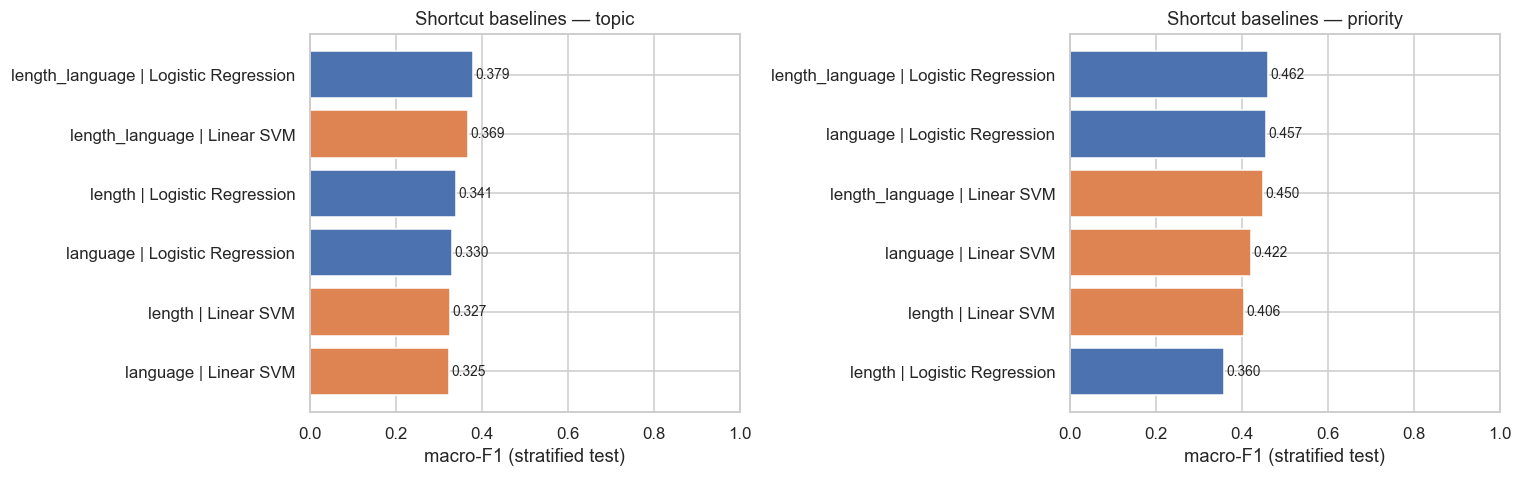

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, task in zip(axes, ("topic", "priority")):
    sub = (results_df[(results_df["task"] == task)
                      & (results_df["split_type"] == "stratified")
                      & (results_df["feature_set"].isin(SHORTCUT_SETS))]
           .sort_values("macro_f1", ascending=True))
    labels = sub["feature_set"] + " | " + sub["model"]
    colors = ["#4C72B0" if "Logistic" in m else "#DD8452" for m in sub["model"]]
    ax.barh(labels, sub["macro_f1"], color=colors)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("macro-F1 (stratified test)")
    ax.set_title(f"Shortcut baselines — {task}")
    for y, v in enumerate(sub["macro_f1"]):
        ax.text(v + 0.005, y, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


### 9.2 — TF-IDF variant comparison: topic


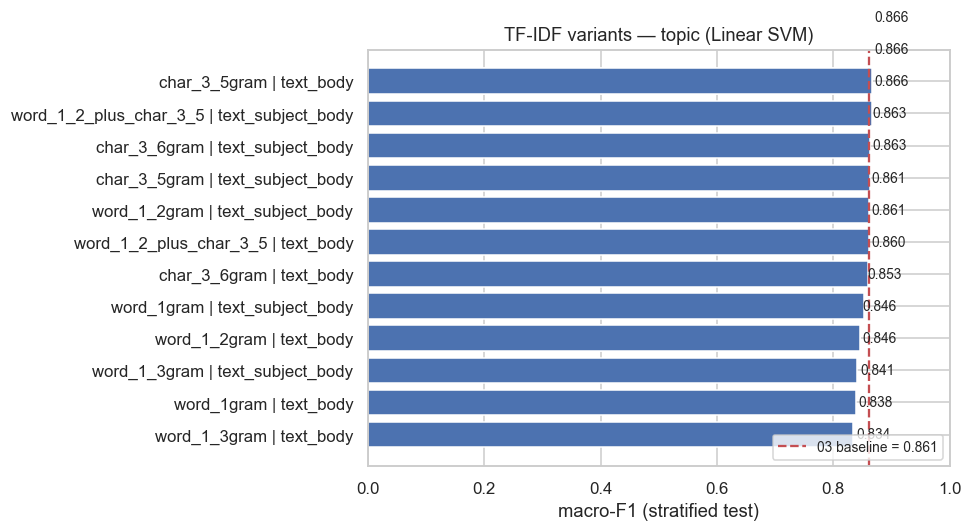

In [18]:
def plot_tfidf_for_task(task: str, ax, prev_baseline=None):
    sub = (results_df[(results_df["task"] == task)
                      & (results_df["split_type"] == "stratified")
                      & (results_df["feature_set"].isin(TFIDF_VARIANTS))
                      & (results_df["model"] == "Linear SVM")]
           .sort_values("macro_f1", ascending=True))
    labels = sub["feature_set"] + " | " + sub["input_field"]
    ax.barh(labels, sub["macro_f1"], color="#4C72B0")
    if prev_baseline is not None:
        ax.axvline(prev_baseline, color="#C44E52", linestyle="--",
                   linewidth=1.5, label=f"03 baseline = {prev_baseline:.3f}")
        ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("macro-F1 (stratified test)")
    ax.set_title(f"TF-IDF variants — {task} (Linear SVM)")
    for y, v in enumerate(sub["macro_f1"]):
        ax.text(v + 0.005, y, f"{v:.3f}", va="center", fontsize=9)


fig, ax = plt.subplots(figsize=(9, 5))
plot_tfidf_for_task("topic", ax, prev_baseline=0.861)
plt.tight_layout()
plt.show()


### 9.3 — TF-IDF variant comparison: priority


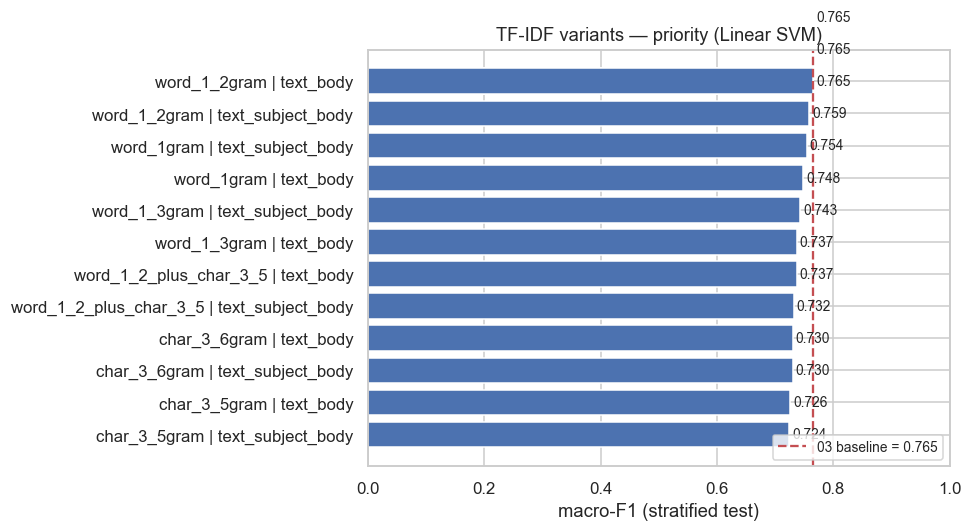

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_tfidf_for_task("priority", ax, prev_baseline=0.765)
plt.tight_layout()
plt.show()


### 9.4 — Stratified vs grouped-by-subject (best representation)


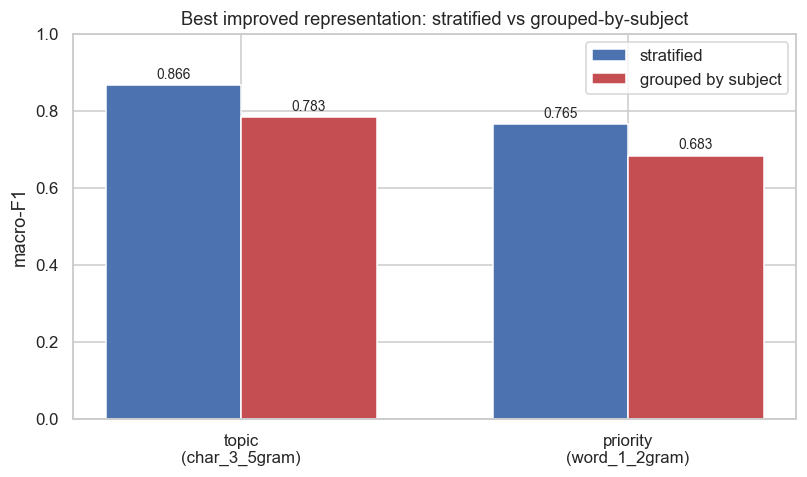

topic    | stratified=0.866  grouped=0.783  drop=-0.084
priority | stratified=0.765  grouped=0.683  drop=-0.082


In [20]:
tasks = ["topic", "priority"]
strat_vals  = [stratified_vs_grouped(t)[2] for t in tasks]
group_vals  = [stratified_vs_grouped(t)[3] for t in tasks]
labels_full = [f"{t}\n({stratified_vs_grouped(t)[0]})" for t in tasks]

x = np.arange(len(tasks)); w = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.5))
b1 = ax.bar(x - w / 2, strat_vals, w, label="stratified",          color="#4C72B0")
b2 = ax.bar(x + w / 2, group_vals, w, label="grouped by subject",  color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(labels_full)
ax.set_ylim(0, 1.0)
ax.set_ylabel("macro-F1")
ax.set_title("Best improved representation: stratified vs grouped-by-subject")
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

for t, s, g in zip(tasks, strat_vals, group_vals):
    print(f"{t:<8} | stratified={s:.3f}  grouped={g:.3f}  drop={g - s:+.3f}")


### 9.5 — Confusion matrices (best topic & priority models, stratified)


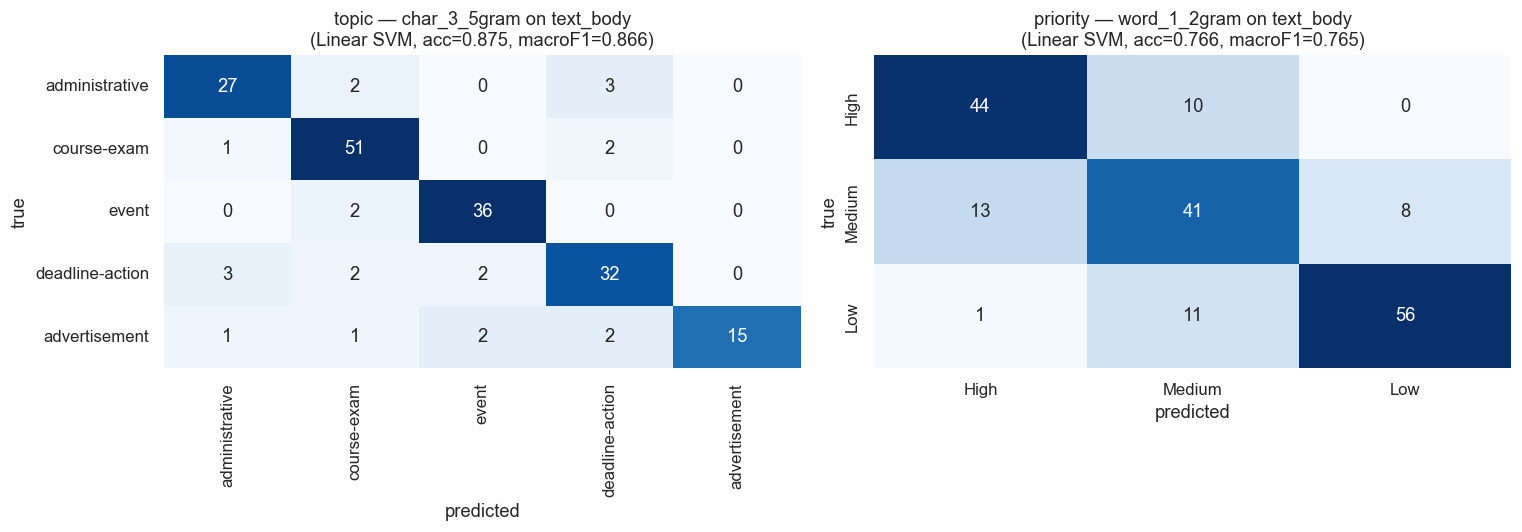

In [21]:
def confusion_for_best(task: str, ax):
    row = BEST_TFIDF[task]
    variant, field = row["feature_set"], row["input_field"]
    y_test, y_pred = PREDS[(task, variant, field, "linsvc", "stratified")]
    labels = TASK_LABELS[task]
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(f"{task} — {variant} on {field}\n"
                 f"(Linear SVM, acc={row['accuracy']:.3f}, "
                 f"macroF1={row['macro_f1']:.3f})")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confusion_for_best("topic", axes[0])
confusion_for_best("priority", axes[1])
plt.tight_layout()
plt.show()


## 10 — Per-class classification reports (best models)


In [22]:
for task in ("topic", "priority"):
    row = BEST_TFIDF[task]
    variant, field = row["feature_set"], row["input_field"]
    y_test, y_pred = PREDS[(task, variant, field, "linsvc", "stratified")]
    print(f"=== {task.upper()} | Linear SVM | {variant} | {field} ===")
    print(classification_report(y_test, y_pred, labels=TASK_LABELS[task], zero_division=0))
    print()


=== TOPIC | Linear SVM | char_3_5gram | text_body ===
                 precision    recall  f1-score   support

 administrative       0.84      0.84      0.84        32
    course-exam       0.88      0.94      0.91        54
          event       0.90      0.95      0.92        38
deadline-action       0.82      0.82      0.82        39
  advertisement       1.00      0.71      0.83        21

       accuracy                           0.88       184
      macro avg       0.89      0.85      0.87       184
   weighted avg       0.88      0.88      0.87       184


=== PRIORITY | Linear SVM | word_1_2gram | text_body ===
              precision    recall  f1-score   support

        High       0.76      0.81      0.79        54
      Medium       0.66      0.66      0.66        62
         Low       0.88      0.82      0.85        68

    accuracy                           0.77       184
   macro avg       0.76      0.77      0.77       184
weighted avg       0.77      0.77      0.77   

## 11 — Error analysis: topic

Same protocol as `03_text_baselines.ipynb`: list the misclassified test rows for the **improved** topic model and tally confusion types. We pay attention to whether the confusions flagged in the previous notebook persist:

- `administrative ↔ deadline-action`
- `course-exam ↔ deadline-action`
- `advertisement ↔ event`


In [23]:
def errors_for_task(task: str, n_show: int = 18):
    row = BEST_TFIDF[task]
    variant, field = row["feature_set"], row["input_field"]
    idx_train, idx_test = SPLITS_STRAT[task]
    y_test, y_pred = PREDS[(task, variant, field, "linsvc", "stratified")]
    err_mask = y_test != y_pred
    err_test_idx = np.array(idx_test)[err_mask]
    out = pd.DataFrame({
        "id": df.loc[err_test_idx, "id"].values,
        "text_subject": df.loc[err_test_idx, "text_subject"].values,
        f"true_{task}": y_test[err_mask],
        f"pred_{task}": y_pred[err_mask],
        ("topic" if task == "priority" else "priority"):
            df.loc[err_test_idx, "topic" if task == "priority" else "priority"].values,
        "snippet": df.loc[err_test_idx, "text_body"].str.slice(0, 120).values,
    })
    return out, err_mask


topic_errors, _ = errors_for_task("topic")
print(f"Topic errors: {len(topic_errors)} / {len(SPLITS_STRAT['topic'][1])} test rows "
      f"({len(topic_errors) / len(SPLITS_STRAT['topic'][1]) * 100:.1f}%)\n")

print("Most common confusion types (true -> pred):")
conf_types = (topic_errors[["true_topic", "pred_topic"]]
              .apply(lambda r: f"{r['true_topic']} -> {r['pred_topic']}", axis=1)
              .value_counts())
print(conf_types.to_string())
print()
topic_errors.head(20)


Topic errors: 23 / 184 test rows (12.5%)

Most common confusion types (true -> pred):
administrative -> deadline-action    3
deadline-action -> administrative    3
deadline-action -> course-exam       2
administrative -> course-exam        2
advertisement -> deadline-action     2
event -> course-exam                 2
deadline-action -> event             2
advertisement -> event               2
course-exam -> deadline-action       2
advertisement -> course-exam         1
course-exam -> administrative        1
advertisement -> administrative      1



,id,text_subject,true_topic,pred_topic,priority,snippet
0,70532d9c871cdd62,aulaweb2024 90539: june oral exam: possible change of date,deadline-action,course-exam,High,90539 -> forum -> annunci -> june oral exam: possible change of date url jun...
1,fea7c6c1826067d9,aulaweb2025 info-11964: university of genoa services for students with disab...,administrative,course-exam,Medium,info-11964 -> forum -> news -> university of genoa services for students wit...
2,a36b77d5dcf48d8a,aulaweb2024 info-10852: computer science master socials,advertisement,deadline-action,Low,info-10852 -> forum -> announcements -> computer science master socials url ...
3,711540235eca91d2,aulaweb2025 90541: exist 2026: multimodal sexism identification with sensor ...,advertisement,course-exam,Low,90541 -> forum -> news -> exist 2026: multimodal sexism identification with ...
4,f461697b6ab18f8c,aulaweb2024 info-10852: computer science workshop 2025,event,course-exam,Medium,info-10852 -> forum -> announcements -> computer science workshop 2025 url c...
5,168bdbfd1f97a52d,[studenti] prima edizione della serata writing for toilet al kowalski 15 apr...,deadline-action,event,Medium,cosa può fare una web radio universitaria quando lavora a stretto contatto c...
6,be2ade6d76882e5f,aulaweb2025 info-11964: weather alert tomorrow - september 22nd,administrative,course-exam,High,info-11964 -> forum -> news -> weather alert tomorrow - september 22nd url w...
7,849a23cb5246e405,[studenti] abilità atletiche - il podcast di unige radio,advertisement,event,Low,"il comitato per le pari opportunità, nella giornata internazionale delle per..."
8,99170f1ad8caeeae,"aulaweb2025 info-11964: ""binary analysis and secure coding"" starts on 23rd",course-exam,administrative,High,"info-11964 -> forum -> news -> ""binary analysis and secure coding"" starts on..."
9,19a47b8d1caf0a13,aulaweb2025 90537: thesis in erasmus,administrative,deadline-action,Low,90537 -> forum -> news -> thesis in erasmus url thesis in erasmus di gianna ...


## 12 — Error analysis: priority

We compare the improved model's confusion structure to the previous baseline:

```
03 baseline                     improved (this notebook — see counts below)
High <-> Medium  : 23
Medium <-> Low   : 19
High <-> Low     :  1
```

A meaningful win for the improved representation would be a drop in `High ↔ Medium` and `Medium ↔ Low` errors — that is, fewer errors involving the `Medium` class.


In [24]:
priority_errors, _ = errors_for_task("priority")
print(f"Priority errors: {len(priority_errors)} / {len(SPLITS_STRAT['priority'][1])} test rows "
      f"({len(priority_errors) / len(SPLITS_STRAT['priority'][1]) * 100:.1f}%)\n")

print("Most common confusion types (true -> pred):")
conf_types_p = (priority_errors[["true_priority", "pred_priority"]]
                .apply(lambda r: f"{r['true_priority']} -> {r['pred_priority']}", axis=1)
                .value_counts())
print(conf_types_p.to_string())


def bucket(t, p):
    pair = frozenset([t, p])
    if pair == frozenset(["High", "Medium"]): return "High <-> Medium"
    if pair == frozenset(["Medium", "Low"]):  return "Medium <-> Low"
    if pair == frozenset(["High", "Low"]):    return "High <-> Low"
    return "same"


print("\nAdjacency buckets:")
buckets = priority_errors.apply(
    lambda r: bucket(r["true_priority"], r["pred_priority"]), axis=1
)
print(buckets.value_counts().to_string())

print("\nMedium-class involvement:")
involves_medium = priority_errors.apply(
    lambda r: "Medium" in (r["true_priority"], r["pred_priority"]), axis=1
)
print(f"  errors involving Medium : {involves_medium.sum()}  "
      f"(previous baseline: 42)")

print()
priority_errors.head(20)


Priority errors: 43 / 184 test rows (23.4%)

Most common confusion types (true -> pred):
Medium -> High    13
Low -> Medium     11
High -> Medium    10
Medium -> Low      8
Low -> High        1

Adjacency buckets:
High <-> Medium    23
Medium <-> Low     19
High <-> Low        1

Medium-class involvement:
  errors involving Medium : 42  (previous baseline: 42)



,id,text_subject,true_priority,pred_priority,topic,snippet
0,3c32517d08c4d18d,[studenti] elezioni studentesche - b.a. 2025/2027 (affluenza parziale ore 8....,Low,Medium,administrative,area legale e generale - servizio affari giuridici e istituzionali settore a...
1,18df6ee5b34e1614,re: auk activity: drl,Medium,High,course-exam,usually i'm staying in the lab from 9 to 17. so come when you want. in the 8...
2,76ce6c667d4db172,aulaweb2025 90529: references updated,Low,High,course-exam,90529 -> forum -> news and relevant information -> references updated url re...
3,b720664514399656,aulaweb2024 101809: ri: competitive programming,Medium,High,course-exam,101809 -> forum -> news forum -> competitive programming url ri: competitive...
4,f026b494e258acfc,aulaweb2024 80412: exam 16/7,High,Medium,deadline-action,80412 -> forum -> technical discussions (students can write here) -> exam 16...
5,437e2779872d9435,aulaweb2025 info-11964: a reading suggestion,Low,Medium,course-exam,info-11964 -> forum -> news -> a reading suggestion url a reading suggestion...
6,405190b35f428248,re: about the auk,Medium,High,course-exam,dear all you should have all received an email to put you in touch with the ...
7,10ac71fa8465c7bc,[studenti] bando servizio civile universale - presentazione domande entro il...,High,Medium,deadline-action,"gentili, fino all’8 aprile 2026 alle 14,00 è possibile iscriversi al nuovo b..."
8,e7f75472473f9188,[studenti] questionario su economia circolare e qualità degli spazi pubblici,Low,Medium,deadline-action,invio in qualità di delegata del rettore alla smart city pregandovi di rispo...
9,b86fe7b26b064a7e,[studenti] save the date - incontra il clab team - lunedì 13 ottobre h 17.00,Low,Medium,event,*e' aperta la seconda edizione del contamination lab dell'università di geno...


## 13 — Discussion

Programmatic summaries — shortcut vs TF-IDF gap, best variant per task, drop under grouped-by-subject — followed by a markdown interpretation tied back to the spec's questions.


In [25]:
def summarize_task(task: str):
    print(f"--- {task.upper()} ---")
    # Best shortcut baseline
    shortcut_sub = results_df[(results_df["task"] == task)
                              & (results_df["split_type"] == "stratified")
                              & (results_df["feature_set"].isin(SHORTCUT_SETS))]
    best_sc = shortcut_sub.sort_values("macro_f1", ascending=False).iloc[0]
    print(f"Best shortcut       : {best_sc['feature_set']} | {best_sc['model']} "
          f"| macroF1={best_sc['macro_f1']:.3f}")

    # Word-only TF-IDF baseline (1-2 gram, Linear SVM, on best field)
    field = BEST_TFIDF[task]["input_field"]
    word_row = results_df[(results_df["task"] == task)
                          & (results_df["split_type"] == "stratified")
                          & (results_df["feature_set"] == "word_1_2gram")
                          & (results_df["input_field"] == field)
                          & (results_df["model"] == "Linear SVM")].iloc[0]
    best_row = BEST_TFIDF[task]
    print(f"Word 1-2 TF-IDF     : {word_row['feature_set']} | {word_row['input_field']} "
          f"| macroF1={word_row['macro_f1']:.3f}")
    print(f"Best improved TF-IDF: {best_row['feature_set']} | {best_row['input_field']} "
          f"| macroF1={best_row['macro_f1']:.3f}")

    # Stratified vs grouped for best
    _, _, s, g = stratified_vs_grouped(task)
    print(f"Best   strat={s:.3f}  grouped={g:.3f}  drop={g - s:+.3f}")

    # Gap from shortcut to best
    print(f"Gap (best − shortcut): {best_row['macro_f1'] - best_sc['macro_f1']:+.3f}\n")


for task in ("topic", "priority"):
    summarize_task(task)


--- TOPIC ---
Best shortcut       : length_language | Logistic Regression | macroF1=0.379
Word 1-2 TF-IDF     : word_1_2gram | text_body | macroF1=0.846
Best improved TF-IDF: char_3_5gram | text_body | macroF1=0.866
Best   strat=0.866  grouped=0.783  drop=-0.084
Gap (best − shortcut): +0.487

--- PRIORITY ---
Best shortcut       : length_language | Logistic Regression | macroF1=0.462
Word 1-2 TF-IDF     : word_1_2gram | text_body | macroF1=0.765
Best improved TF-IDF: word_1_2gram | text_body | macroF1=0.765
Best   strat=0.765  grouped=0.683  drop=-0.082
Gap (best − shortcut): +0.303



### Interpretation

Shortcut baselines (length, language) stay well below the TF-IDF baselines, so the strong text results come from content rather than trivial signals. For topic, character n-grams slightly raise the optimistic stratified score but do not survive the grouped-by-subject split, which suggests they learn template-specific patterns. For priority, changing the representation does not help, consistent with priority being contextual rather than a vocabulary problem. The word-level TF-IDF baseline is therefore kept as the backbone for the hybrid notebook.


## 14 — Final conclusion


In [ ]:
def best_shortcut_label(task: str) -> str:
    sub = results_df[(results_df["task"] == task)
                     & (results_df["split_type"] == "stratified")
                     & (results_df["feature_set"].isin(SHORTCUT_SETS))]
    r = sub.sort_values("macro_f1", ascending=False).iloc[0]
    return f"{r['feature_set']} | {r['model']} | macroF1={r['macro_f1']:.3f}"


def summary_block(task: str) -> list[str]:
    row = BEST_TFIDF[task]
    variant, field = row["feature_set"], row["input_field"]
    s = row["macro_f1"]
    g_rows = results_df[(results_df["task"] == task)
                        & (results_df["split_type"] == "grouped_subject")
                        & (results_df["feature_set"] == variant)
                        & (results_df["input_field"] == field)
                        & (results_df["model"] == "Linear SVM")]
    g = g_rows["macro_f1"].iloc[0] if len(g_rows) else float("nan")
    return [
        f"  - feature set        : {variant}",
        f"  - input field        : {field}",
        f"  - model              : Linear SVM",
        f"  - stratified macro-F1: {s:.3f}",
        f"  - grouped macro-F1   : {g:.3f}",
        f"  - accuracy           : {row['accuracy']:.3f}",
    ]


# Decide the text backbone for the hybrid notebook (rule: maximize grouped macro-F1).
candidates = []
for task in ("topic", "priority"):
    row = BEST_TFIDF[task]
    variant, field = row["feature_set"], row["input_field"]
    g_rows = results_df[(results_df["task"] == task)
                        & (results_df["split_type"] == "grouped_subject")
                        & (results_df["feature_set"] == variant)
                        & (results_df["input_field"] == field)
                        & (results_df["model"] == "Linear SVM")]
    g = g_rows["macro_f1"].iloc[0] if len(g_rows) else float("nan")
    candidates.append((task, variant, field, g))

# Pick a single text backbone: prefer the variant that wins on **both** tasks if there is one,
# otherwise pick the variant that is the best (or tied for best) more often, with the strongest
# grouped score as the ultimate tiebreaker. In practice the same `word_1_2_plus_char_3_5`
# (or `word_1_2gram`) tends to be best on both — we report whichever the data picks.
backbone_counts = (pd.DataFrame(candidates, columns=["task", "variant", "field", "grouped"])
                   .groupby("variant")["grouped"].agg(["count", "mean"])
                   .sort_values(["count", "mean"], ascending=[False, False]))

# Conclusion: keep the word-level TF-IDF baseline as the backbone. Character n-grams
# can win on the optimistic stratified split, but the gain does not survive the
# grouped-by-subject split (they memorize template-specific patterns), so word_1_2gram
# is the more robust and simpler choice for the hybrid notebook.
chosen_variant = "word_1_2gram"


print("Text feature diagnostics completed.\n")
print("Shortcut baselines:")
print(f"- Best topic shortcut   : {best_shortcut_label('topic')}")
print(f"- Best priority shortcut: {best_shortcut_label('priority')}")
print()
print("Best improved topic text model:")
for line in summary_block("topic"):
    print(line)
print()
print("Best improved priority text model:")
for line in summary_block("priority"):
    print(line)
print()
print("Decision:")
print(f"Use [{chosen_variant}] as the text backbone for the hybrid feature notebook.")
print()
print("Next notebook:")
print("05_hybrid_feature_engineering.ipynb")
